# **[ Kaggle ] Keras CNN Dog or Cat Classification**
🔗 https://www.kaggle.com/code/uysimty/keras-cnn-dog-or-cat-classification

# Import Library

In [1]:
import numpy as np
import pandas as pd 
from keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
print(os.listdir("../input"))


Using TensorFlow backend.


['test1.zip', 'train.zip', 'sampleSubmission.csv']


In [10]:
import zipfile
zipfile.ZipFile('../input/test1.zip').extractall()

In [11]:
zipfile.ZipFile('../input/train.zip').extractall()

# Define Constants

In [2]:
FAST_RUN = False
IMAGE_WIDTH=128
IMAGE_HEIGHT=128
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS=3

# Prepare Traning Data

In [16]:
filenames = os.listdir("./train")
categories = []
for filename in filenames:
    category = filename.split('.')[0]
    if category == 'dog':
        categories.append(1)
    else:
        categories.append(0)

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

In [17]:
df.head()

,filename,category
0,cat.11467.jpg,0
1,dog.10664.jpg,1
2,cat.2605.jpg,0
3,dog.5375.jpg,1
4,dog.1494.jpg,1


In [18]:
df.tail()

,filename,category
24995,cat.3727.jpg,0
24996,dog.3987.jpg,1
24997,dog.7160.jpg,1
24998,cat.5960.jpg,0
24999,dog.10169.jpg,1


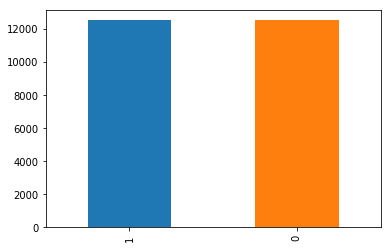

In [19]:
df['category'].value_counts().plot.bar()

- 각 12000개의 cats, dogs image

# See sample image

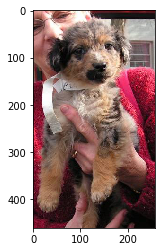

In [20]:
sample = random.choice(filenames)
image = load_img("./train/"+sample)
plt.imshow(image)

# Build Model

<img src="https://i.imgur.com/ebkMGGu.jpg" width="100%"/>

- Input layer: reshape image into single diminsion array
- Conv Layer: extract features
- Pooling Layer: reduce the spatial volume of input image
- Fully Connected Layer: connect the network from a layer to another layer
- Output Layer: predicted value

In [21]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax')) # 2 because we have cat and dog classes

model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model.summary()

Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 126, 126, 32)      896       
_________________________________________________________________
batch_normalization_1 (Batch (None, 126, 126, 32)      128       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 63, 63, 32)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 63, 63, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 61, 61, 64)        18496     
_________________________________________________________________
batch_normalization_2

# Callbacks

In [22]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
earlystop = EarlyStopping(patience=10)

- **Early Stop:** over fitting을 막기 위해 10 epochs동안 val_loss value가 감소하지 않으면 학습 종료

In [24]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', 
                                            patience=2, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.00001)

- **Learning Rate Reduction:** accuracy가 2 steps동안 증가하지 않으면 learning rate 줄이기

In [25]:
callbacks = [earlystop, learning_rate_reduction]

# Prepare data

`class_mode="categorical"`로 image generator 사용

➡️ categori column을 string으로 변환하고 one-hot encoding 수행

In [26]:
df["category"] = df["category"].replace({0: 'cat', 1: 'dog'}) 

In [27]:
train_df, validate_df = train_test_split(df, test_size=0.20, random_state=42)
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

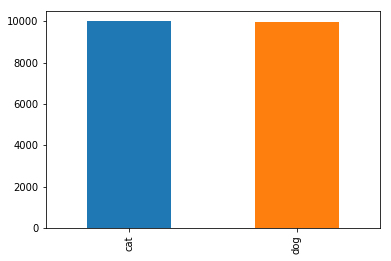

In [28]:
train_df['category'].value_counts().plot.bar()

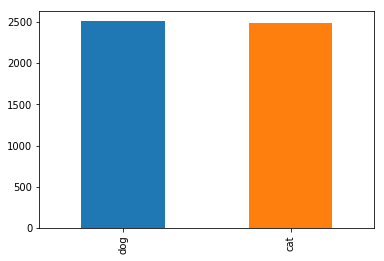

In [29]:
validate_df['category'].value_counts().plot.bar()

In [30]:
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]
batch_size=15

# Traning Generator

In [35]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = train_datagen.flow_from_dataframe(
    train_df, 
    "./train/", 
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)

Found 20000 images belonging to 2 classes.


### Validation Generator

In [37]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df, 
    "./train/", 
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    class_mode='categorical',
    batch_size=batch_size
)

Found 5000 images belonging to 2 classes.


# See how our generator work

In [38]:
example_df = train_df.sample(n=1).reset_index(drop=True)
example_generator = train_datagen.flow_from_dataframe(
    example_df, 
    "./train/", 
    x_col='filename',
    y_col='category',
    target_size=IMAGE_SIZE,
    class_mode='categorical'
)

Found 1 images belonging to 1 classes.


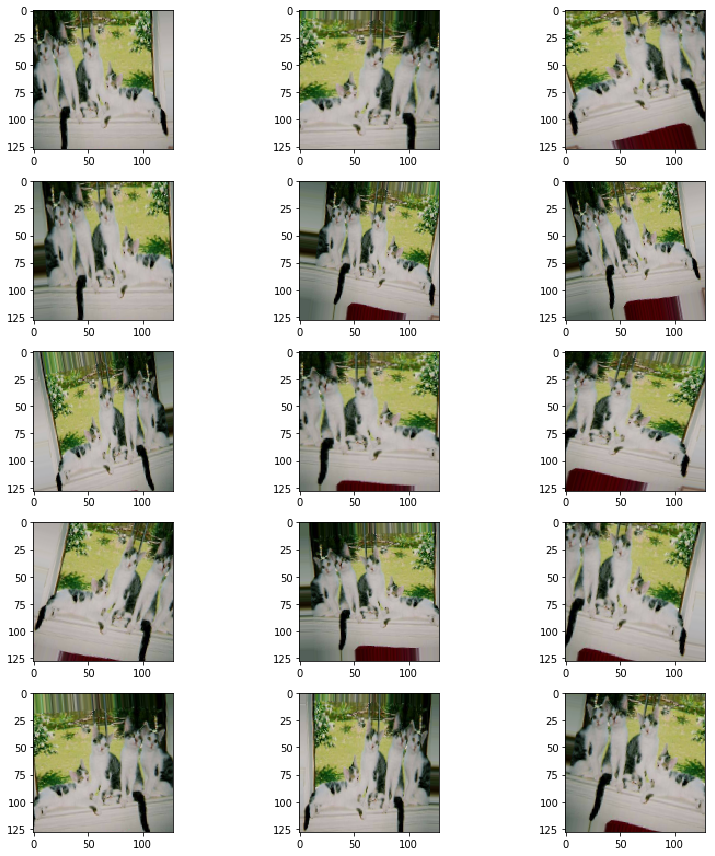

In [39]:
plt.figure(figsize=(12, 12))
for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

# Fit Model

In [40]:
epochs=3 if FAST_RUN else 50
history = model.fit_generator(
    train_generator, 
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=total_validate//batch_size,
    steps_per_epoch=total_train//batch_size,
    callbacks=callbacks
)

Instructions for updating:
Use tf.cast instead.
Epoch 1/50
1333/1333 [==============================] - 160s 120ms/step - loss: 0.7447 - acc: 0.6348 - val_loss: 0.5763 - val_acc: 0.6893
Epoch 2/50
1333/1333 [==============================] - 156s 117ms/step - loss: 0.5529 - acc: 0.7252 - val_loss: 0.6339 - val_acc: 0.7188
Epoch 3/50
1333/1333 [==============================] - 156s 117ms/step - loss: 0.4931 - acc: 0.7656 - val_loss: 0.5190 - val_acc: 0.7823
Epoch 4/50
1333/1333 [==============================] - 155s 117ms/step - loss: 0.4297 - acc: 0.8032 - val_loss: 0.3840 - val_acc: 0.8353
Epoch 6/50
1333/1333 [==============================] - 155s 117ms/step - loss: 0.4091 - acc: 0.8154 - val_loss: 0.4247 - val_acc: 0.8166
Epoch 7/50
1333/1333 [==============================] - 157s 118ms/step - loss: 0.3969 - acc: 0.8266 - val_loss: 0.4127 - val_acc: 0.8130

Epoch 00007: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
Epoch 8/50
1333/1333 [=====================

# Save Model

In [41]:
model.save_weights("model.h5")

# Virtualize Training

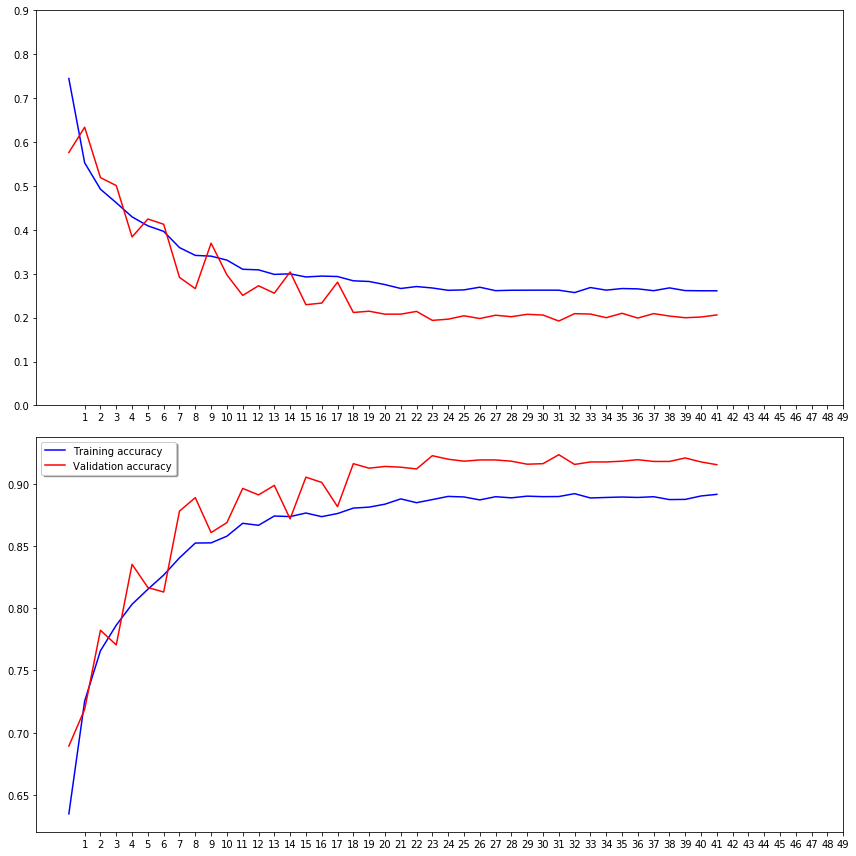

In [42]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
ax1.plot(history.history['loss'], color='b', label="Training loss")
ax1.plot(history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, epochs, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

ax2.plot(history.history['acc'], color='b', label="Training accuracy")
ax2.plot(history.history['val_acc'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, epochs, 1))

legend = plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

# Prepare Testing Data

In [44]:
test_filenames = os.listdir("./test1")
test_df = pd.DataFrame({
    'filename': test_filenames
})
nb_samples = test_df.shape[0]

# Create Testing Generator

In [45]:
test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_dataframe(
    test_df, 
    "./test1/", 
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    shuffle=False
)

Found 12500 images.


# Predict

In [46]:
predict = model.predict_generator(test_generator, steps=np.ceil(nb_samples/batch_size))

categoral classication의 prediction: probability of each category

➡️ 가장 높은 probability로 선택(`numpy.argmax`)

In [49]:
test_df['category'] = np.argmax(predict, axis=-1)

In [54]:
label_map = dict((v,k) for k,v in train_generator.class_indices.items())
test_df['category'] = test_df['category'].replace(label_map)

- 전처리 과정에서 변환한 category(`{1: 'dog', 0: 'cat'}`) 복구

In [55]:
test_df['category'] = test_df['category'].replace({ 'dog': 1, 'cat': 0 })

### Virtaulize Result

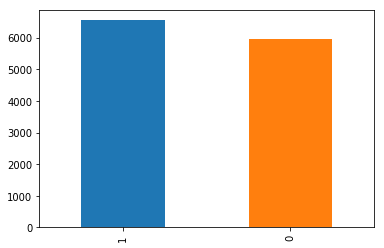

In [56]:
test_df['category'].value_counts().plot.bar()

### See predicted result with images

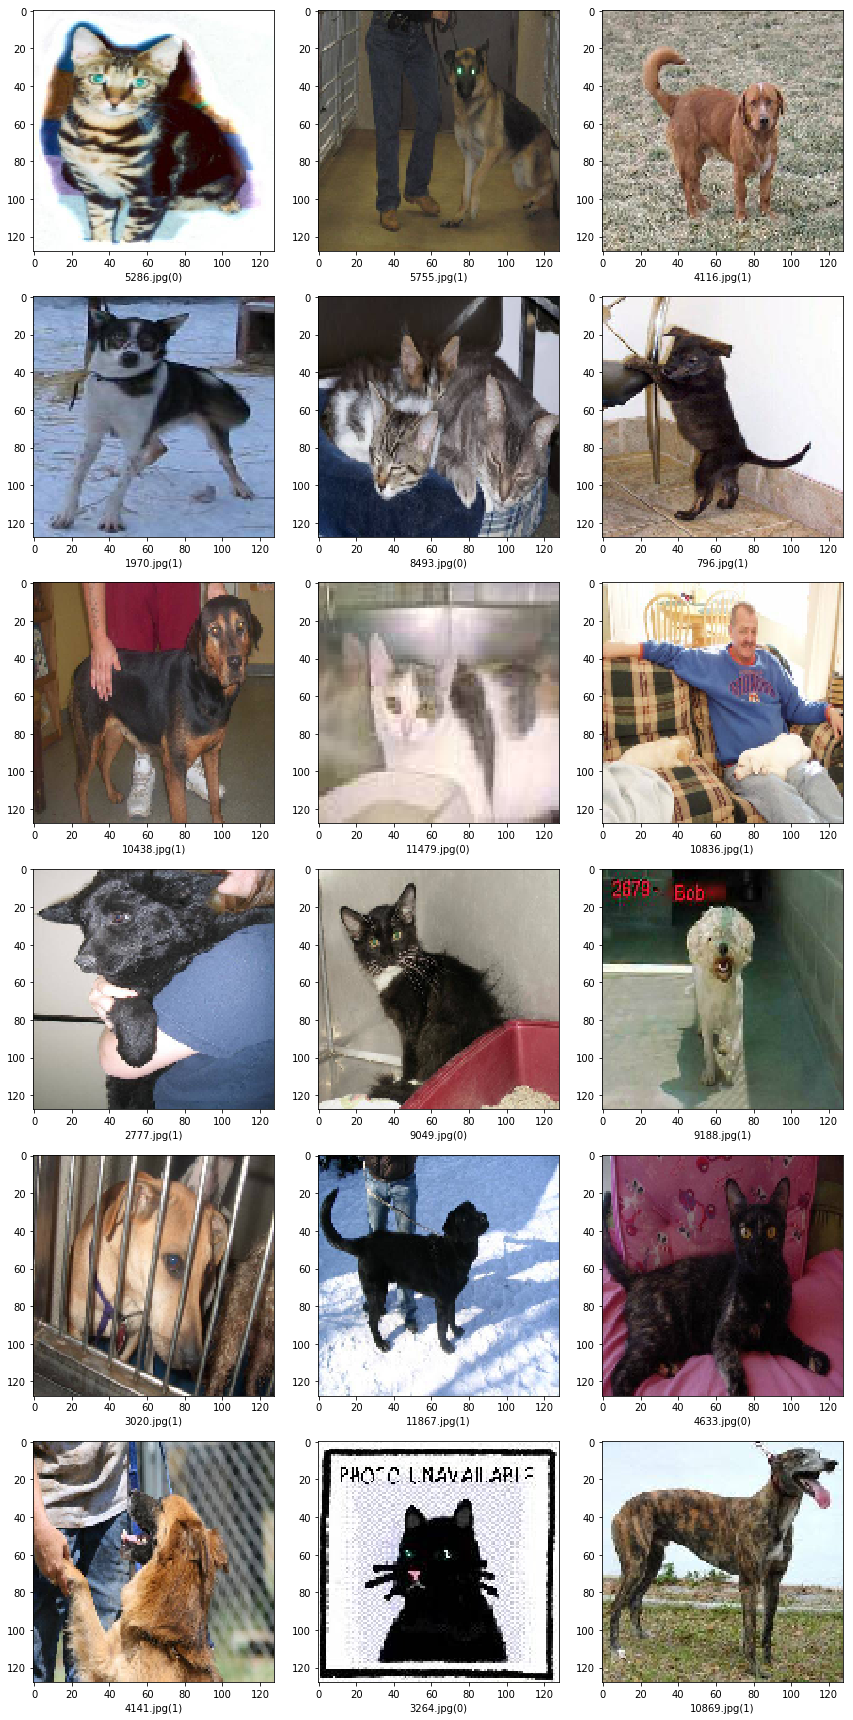

In [57]:
sample_test = test_df.head(18)
sample_test.head()
plt.figure(figsize=(12, 24))
for index, row in sample_test.iterrows():
    filename = row['filename']
    category = row['category']
    img = load_img("./test1/"+filename, target_size=IMAGE_SIZE)
    plt.subplot(6, 3, index+1)
    plt.imshow(img)
    plt.xlabel(filename + '(' + "{}".format(category) + ')' )
plt.tight_layout()
plt.show()

# Submission

In [58]:
submission_df = test_df.copy()
submission_df['id'] = submission_df['filename'].str.split('.').str[0]
submission_df['label'] = submission_df['category']
submission_df.drop(['filename', 'category'], axis=1, inplace=True)
submission_df.to_csv('submission.csv', index=False)